# Uso de Redes Neurais Convolucionais (*Convolutional Neural Networks - CNN*)

Disciplina: Redes Neurais e Deep Learning

Especialização em Ciência de Dados - Universidade Tecnologica Federal do Paraná

Aula 04: CNNs

Exemplo 02: Executando CNN para problema CIFAR-10

Linguagem de programação usada no notebook: **R**

---


Começaremos nosso exemplo teste fazendo a requisição dos pacotes que necessitamos para manipular os modelos de Aprendizado Profundo (*Deep Learning - DL*), no caso as CNNs. Iremos fazer uso de um pacote em especial:
* **keras** - wrapper em R das implementações de DL em Python.

Links externos:

* Keras: https://keras.io

* keras - pacote R: https://cran.r-project.org/web/packages/kerasR/vignettes/introduction.html


In [ ]:
# Caso o pacote keras não exista, ele será instalado
mat = installed.packages("keras")  #lista todos os pacotes instalados no ambiente
if(!"keras" %in% rownames(mat)) {
  install.packages("keras")        #instala se ele nao tiver sido instalado anteriormente
}

# Carregando o pacote keras para R
library("keras")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘Rcpp’, ‘RcppTOML’, ‘here’, ‘png’, ‘config’, ‘tfautograph’, ‘reticulate’, ‘tensorflow’, ‘tfruns’, ‘zeallot’




#1 - Selecionar um conjunto de dados

Iremos trabalhar com um conjunto de dados (*dataset*) composto por imagens. O dataset selecionado para esse exemplo é o [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html). Este dataset é composto por
60 mil imagens, cuja resolução é 32 x 32, dividas em 10 categorias, incluindo imagens de objetos e animais. As 10 categorias existentes no CIFAR-10 são:
* classes = {avião, automóvel, pássaro, gato, veado, cachorro, sapo, cavalo, navio, e caminhão}.

In [ ]:
# carregar o dataset CIFAR-10 do pacote keras
cifar = keras::dataset_cifar10()

Além do cifar, existem outros dataset já pré-carregados no pacote:'dataset_boston_housing()', 'dataset_cifar100()'; 'dataset_fashion_mnist()', 'dataset_imdb()', 'dataset_mnist()', 'dataset_reuters()'.

Dentro variável ```cifar``` teremos quatro conjuntos de dados:
* ```train$x```: conjunto de treinamento e seus respectivos atributos descritivos (pixels de cada imagem);
* ```train$y```: labels do conjunto de treinamento;
* ```test$x```: conjunto de teste e seus respectivos atributos descritivos;
* ```test$y```: labels do conjunto de teste.

Os conjuntos 'x' são arrays de imagens em RGB com dimensão: (num_samples, 32, 32, 3). Já os conjuntos 'y' são arrays categóricos com valores de 0-9, no tamanho (num_samples).


In [ ]:
# Conjunto de treinamento (train$x)
# 50000 imagens no conjunto de treinamento, 32x32, 3 canais de cores (matrizes R, G, B)
str(cifar$train$x)

 int [1:50000, 1:32, 1:32, 1:3] 59 154 255 28 170 159 164 28 134 125 ...


In [ ]:
dim(cifar$train$x)

[1] 50000    32    32     3

In [ ]:
# Tentando ver a informação de uma imagem
# imagem 1 - canal R - 0 - 255
#print(cifar$train$x[1,,,1])
# imagem 1 - canal G 0 - 255
print(cifar$train$x[1,,,2])
# imagem 1 - canal B 0 - 255
#print(cifar$train$x[1,,,3])


      [,1] [,2] [,3] [,4] [,5] [,6] [,7] [,8] [,9] [,10] [,11] [,12] [,13]
 [1,]   62   46   48   54   73   91  107  110  117   120   103    99   115
 [2,]   20    0    8   27   51   82   89   86   87    79    70    67    70
 [3,]   24    7   27   50   72   92   93   82   77    78    79    75    73
 [4,]   25   20   54   63   70   74   72   62   68    84    90    75    77
 [5,]   32   32   65   79   77   77   78   74   72    88    89    68    71
 [6,]   48   53   73   82   88   84   84   77   70    82    81    65    72
 [7,]   69   75   85   84   88   83   74   74   83    94    79    79    71
 [8,]   82   76   90   97   88   81   90   89   86    89    91    70    39
 [9,]  100   82   91   87   81   82   85   85   80    97    94    42    25
[10,]  120  112  114  100   89   86   86   91   97    97    60    35    33
[11,]  122  117  117  108  100  100  102  102  111    87    40    53    45
[12,]  114  109  109   97   92   94   84   74  103    83    60    86    78
[13,]  115  106  105  105

In [ ]:
# Rotulos do conjunto de treinamento (train$x)
str(cifar$train$y)

 int [1:50000, 1] 6 9 9 4 1 1 2 7 8 3 ...


In [ ]:
dim(cifar$train$y)

[1] 50000     1

In [ ]:
# vendo a distribuição de valores das classes no conjunto de treinamento
table(cifar$train$y)


   0    1    2    3    4    5    6    7    8    9 
5000 5000 5000 5000 5000 5000 5000 5000 5000 5000 

Algumas características do dataset carregado:


In [ ]:
str(cifar$test$x)

 int [1:10000, 1:32, 1:32, 1:3] 158 235 158 155 65 179 160 83 23 217 ...


Os correspondetes nomes das classes são:

In [ ]:
class_names = c('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(class_names)

 [1] "airplane"   "automobile" "bird"       "cat"        "deer"      
 [6] "dog"        "frog"       "horse"      "ship"       "truck"     


#2 - Visualizar nossos dados

Vamos iniciar nossa nossa epxloração visualizando um exemplo de imagem do conjunto de treinamento usando o pacote [imager](https://dahtah.github.io/imager/imager.html).


In [ ]:
if(!"imager" %in% rownames(mat)) {
  install.packages("imager")        #instala se ele nao tiver sido instalado anteriormente
}
library("imager")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘igraph’


Loading required package: magrittr


Attaching package: ‘imager’


The following object is masked from ‘package:magrittr’:

    add


The following objects are masked from ‘package:stats’:

    convolve, spectrum


The following object is masked from ‘package:graphics’:

    frame


The following object is masked from ‘package:base’:

    save.image




Warning message in as.cimg.array(cifar$train$x[image.number, , , ]):
“Assuming third dimension corresponds to colour”


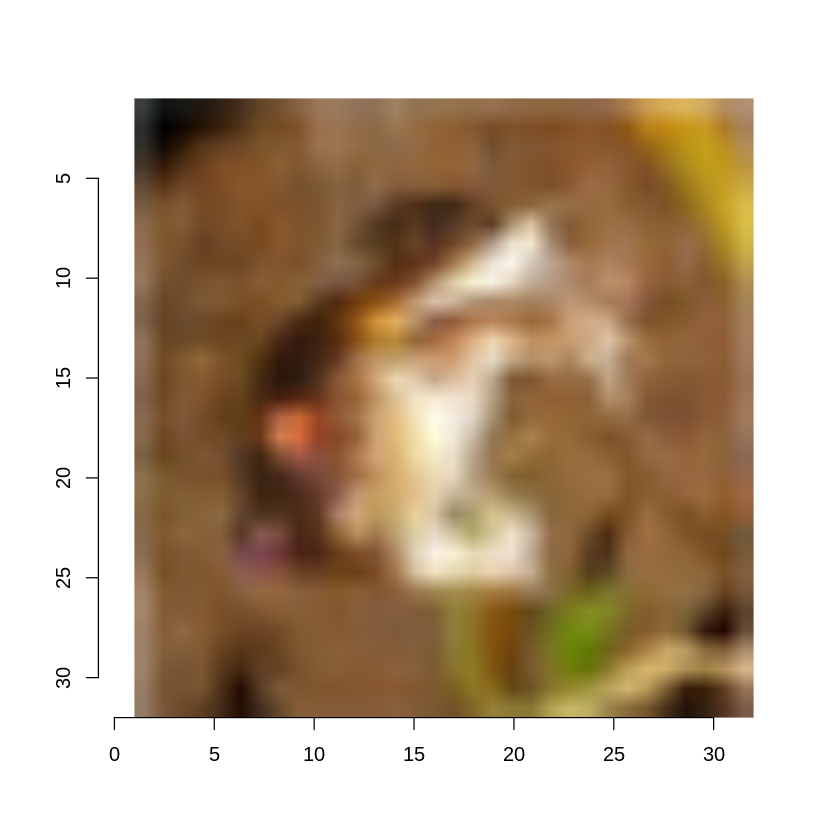

In [ ]:
# id da imagem que queremos visualizar
image.number = 1

# convertemos o array 4D para um objeto de imagem
example = as.cimg(cifar$train$x[image.number,,,])

# plotando a imagem
plot(example) # já é capaz de ver a imagem, mas não agrada visualmente

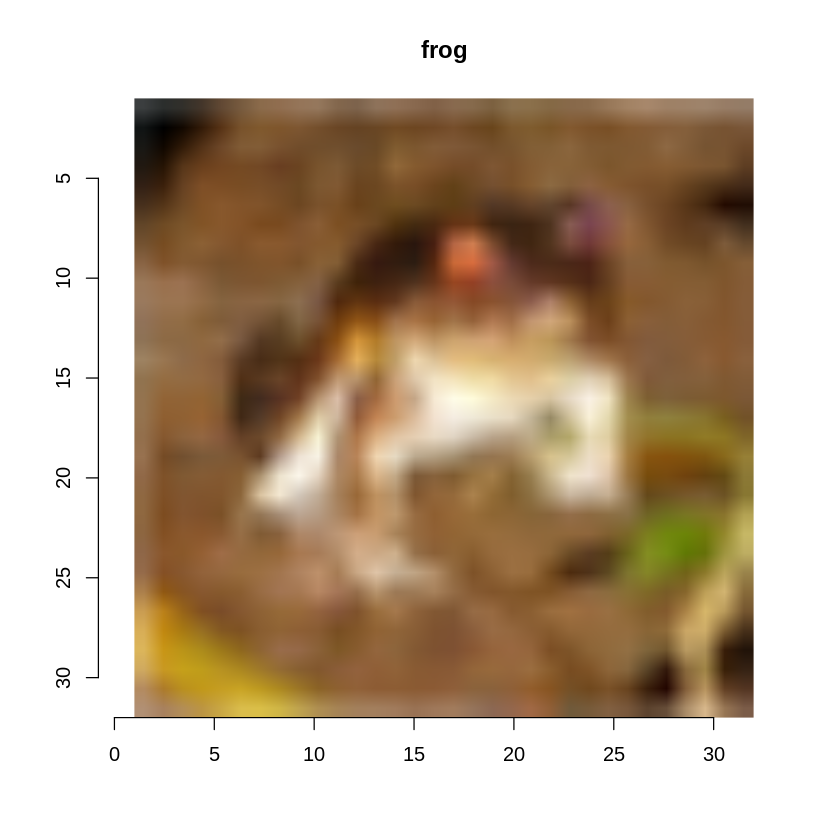

In [ ]:
# comandos para manipular a imagem e vermos de forma agradável :)
imrotate(example,90) %>% mirror("x") %>% plot(main=class_names[cifar$train$y[image.number] + 1])


Podemos tentar visualizar um pouco mais dos dados que estamos manipulando. Logo, seria interessante "ver" estas imagens e como elas diferem entre si (classes). Como temos 50 mil exemplos no conjunto de treinamento vamos selecionar um pequeno subconjunto de 30 imagens e verificar os seus respectivos rótulos (labels/classes).

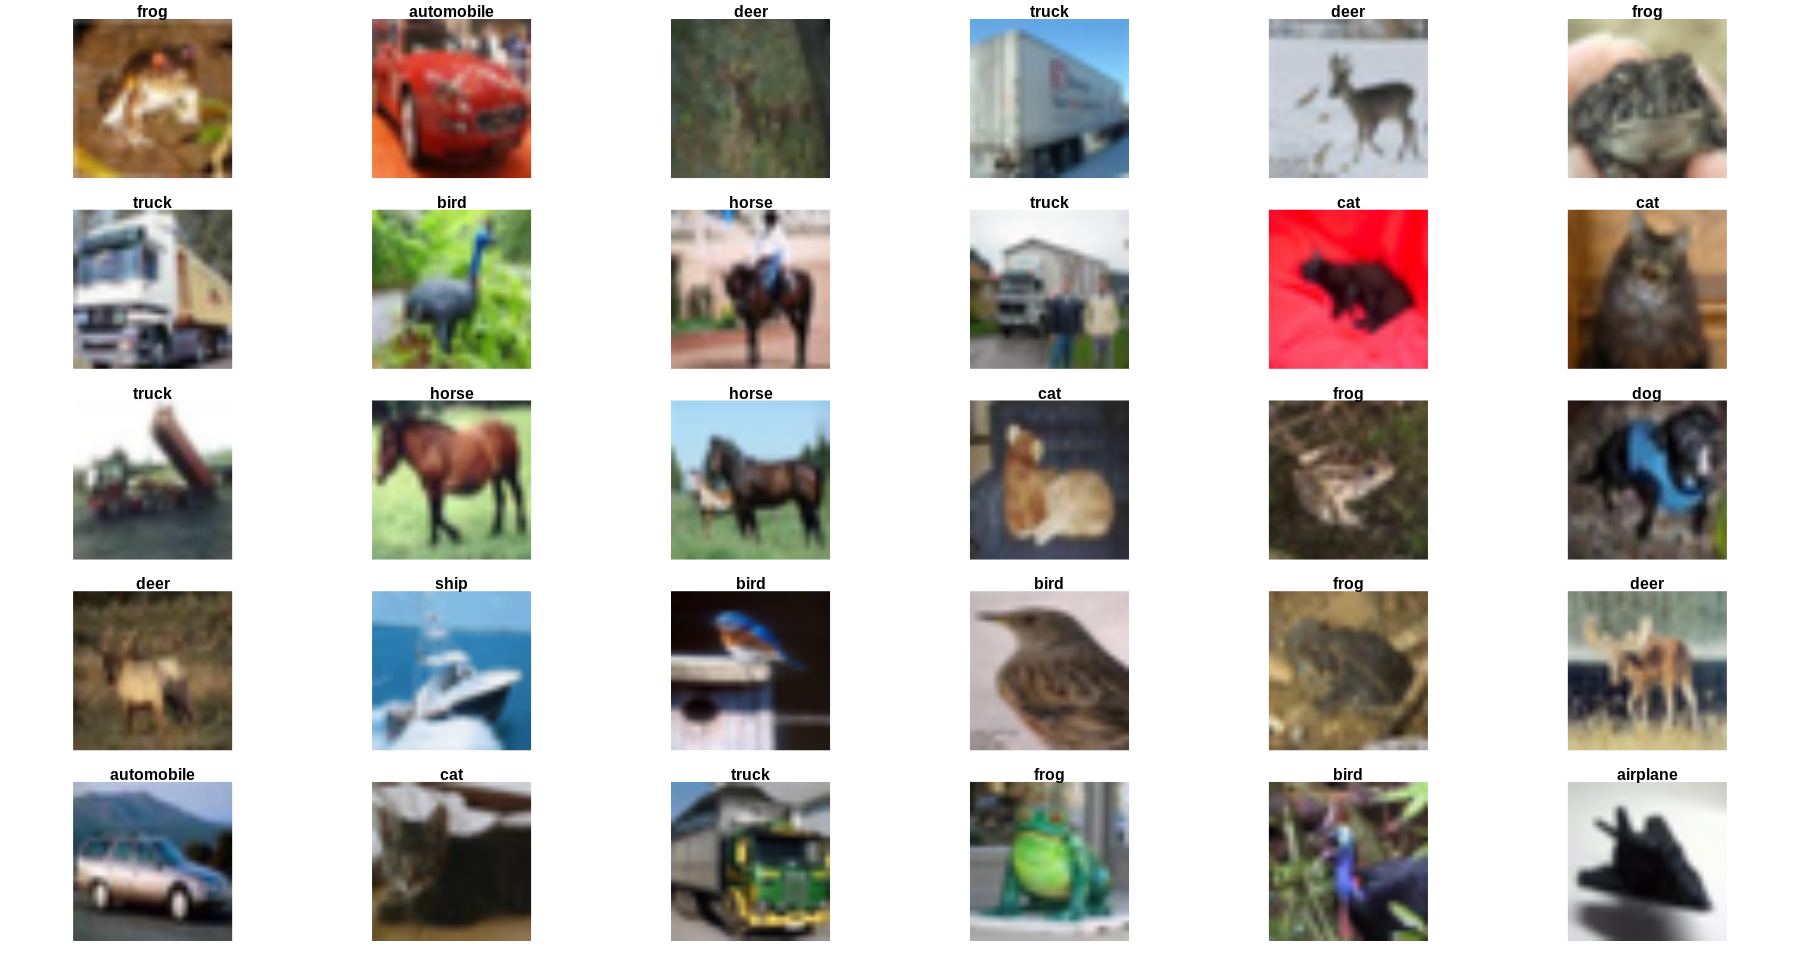

In [ ]:
# selecionaremos 30 imagens
index = 1:30
#index = 31:60
#...

options(repr.plot.width=15, repr.plot.height=8)

# e as mostraremos em um grid 5 x 6 - 5 linhas, 6 colunas
par(mfcol = c(5,6), mar = rep(1, 4), oma = rep(0.2, 4))
cifar$train$x[index,,,] %>%
  purrr::array_tree(1) %>%
  purrr::set_names(class_names[cifar$train$y[index] + 1]) %>%
  purrr::map(as.raster, max = 255) %>%
  purrr::iwalk(~{plot(.x); title(.y)})

# a resolução delas é baixa mesmo :/ imagens 28x28 não contem muita informação
# visual logo, está tudo certo

Seria interessante analisar também qual é a distribução das classes do problema. Podemos entãogerar um histograma para verificar a frequência de cada uma das classes, tanto no conjunto de treiamento (```q1```) como no conjunto de teste (```q2```).

In [ ]:
# gráfico com a distribuição das classes
library('ggplot2')

if(!"gridExtra" %in% rownames(mat)) {
  install.packages("gridExtra")        #instala se ele nao tiver sido instalado anteriormente
}
library('gridExtra')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Warning message:
“`qplot()` was deprecated in ggplot2 3.4.0.”


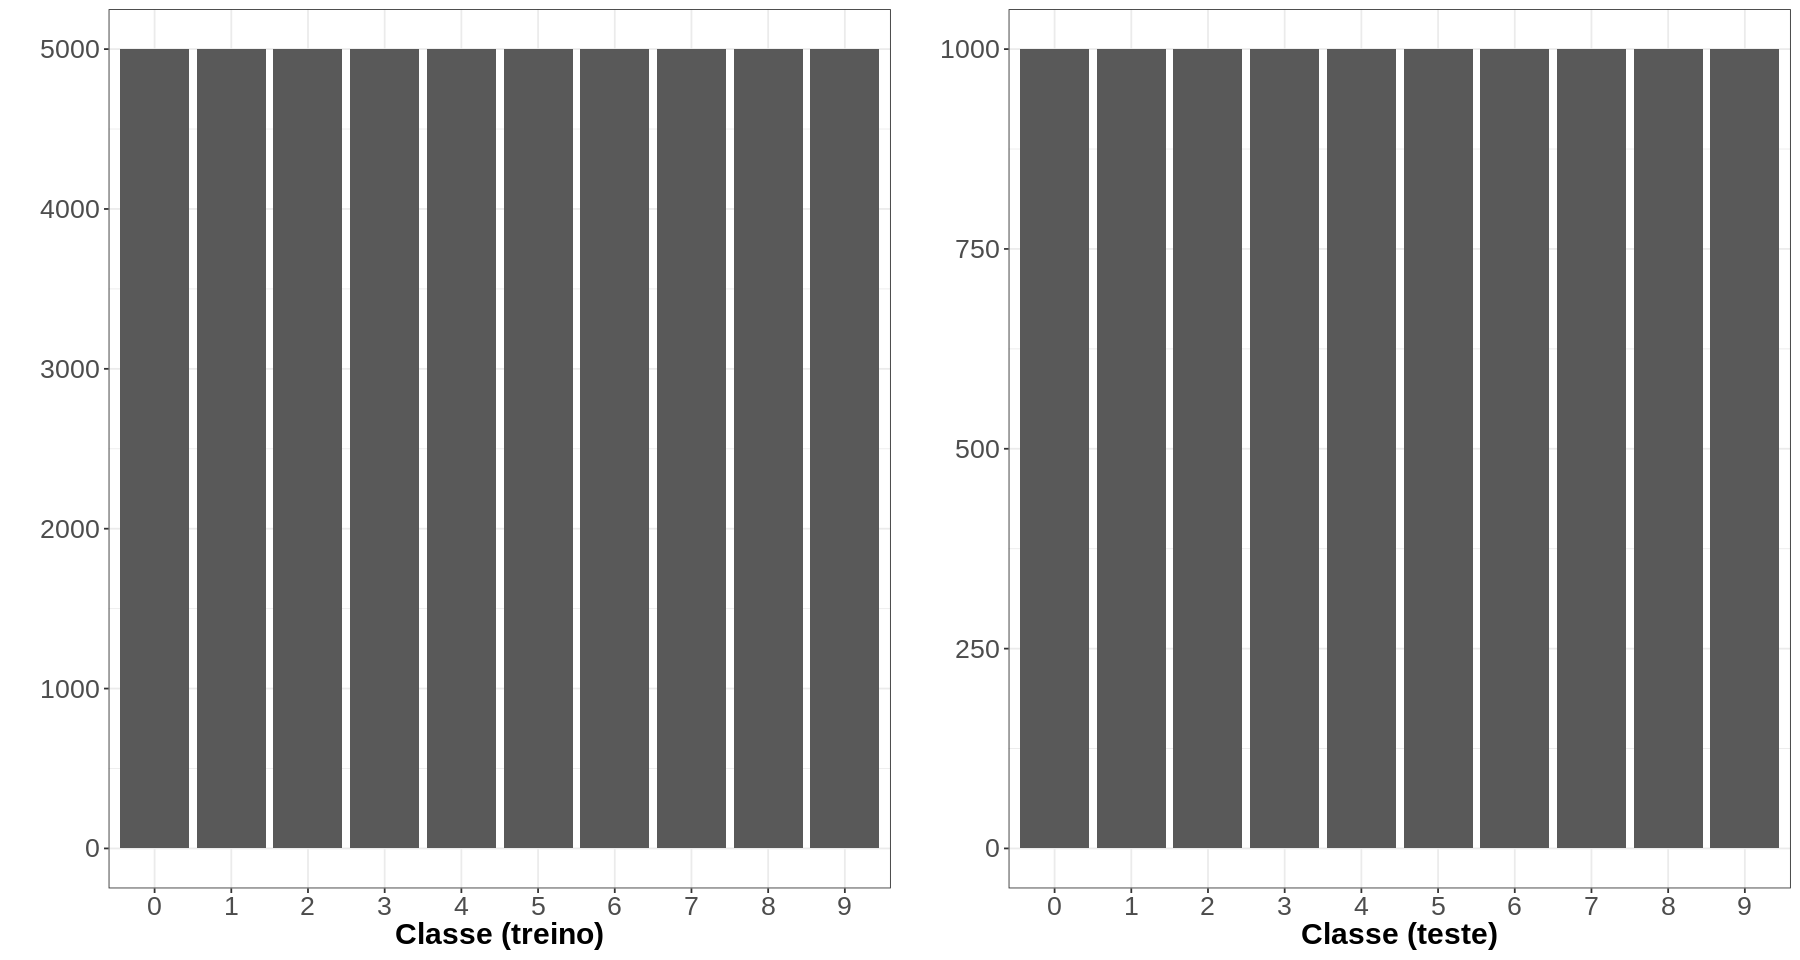

In [ ]:
# histograma das classes no conjunto de treinamento
q1 = qplot(as.factor(cifar$train$y)) + theme_bw() + xlab("Classe (treino)")
q1 = q1 + theme(axis.text=element_text(size=16),
        axis.title=element_text(size=18,face="bold"))

# histograma das classes no conjunto de teste
q2 = qplot(as.factor(cifar$test$y)) + theme_bw() + xlab("Classe (teste)")
q2 = q2 + theme(axis.text=element_text(size=16),
        axis.title=element_text(size=18,face="bold"))

# plot duplo (treino - teste)
options(repr.plot.width=15, repr.plot.height=8)
gridExtra::grid.arrange(q1, q2, ncol=2)

Podemos ver que ambos os cojuntos, treino (esquerda) e teste (direita) são balanceados, ou seja, há a mesma quantidade de exemplos de classes distintas. O que é bom, indicando que temos um bom split de dados para indução e avaliação do modelo.

#3 - Criando um modelo de CNN

Da mesma forma que trabalhamos com as MLPs, vamos inicializar o nosso modelo, isto é, criar a topologia, adicionando as camadas e respectivas funções de ativação da nossa CNN. Nesse exemplo iremos criar uma CNN com 7 camadas:

1.   1a Camada Convolucional
2.   1a Camada de Pooling
3.   2a Camada Convolucional
4.   2a Camada de Pooling
5.   3a Camada Convolucional
6.   1a Camada Densa
7.   2a Camada Densa

Nas camadas da CNN iremos usar funções retificadoras lineares [(R*ectified Linear Units - ReLU*)](https://en.wikipedia.org/wiki/Rectifier_(neural_networks)) como funções de ativação:

```
f(x) = max(0, x)
```

Apenas a última camada (2a camada densa - camada de saída) usará uma função de ativação [softmax](https://en.wikipedia.org/wiki/Softmax_function), para gerar predições em termos de probabilidades para cada classe. A função softmax é uma generalização da função logística para múltiplas dimensões.


In [ ]:
model <- keras_model_sequential() %>%
  # 1. camada convolucional
  layer_conv_2d(filters = 32, kernel_size = c(3,3), activation = "relu", input_shape = c(32,32,3)) %>%
  # 2. pooling
  layer_max_pooling_2d(pool_size = c(2,2)) %>%
  # 3. camada convolucional
  layer_conv_2d(filters = 64, kernel_size = c(3,3), activation = "relu") %>%
  # 4. pooling
  layer_max_pooling_2d(pool_size = c(2,2)) %>%
  # 5. camada convolucional
  layer_conv_2d(filters = 64, kernel_size = c(3,3), activation = "relu")

In [ ]:
summary(model)

Model: "sequential"
________________________________________________________________________________
 Layer (type)                       Output Shape                    Param #     
 conv2d_2 (Conv2D)                  (None, 30, 30, 32)              896         
 max_pooling2d_1 (MaxPooling2D)     (None, 15, 15, 32)              0           
 conv2d_1 (Conv2D)                  (None, 13, 13, 64)              18496       
 max_pooling2d (MaxPooling2D)       (None, 6, 6, 64)                0           
 conv2d (Conv2D)                    (None, 4, 4, 64)                36928       
Total params: 56,320
Trainable params: 56,320
Non-trainable params: 0
________________________________________________________________________________


Adicionamos agora as duas últimas camadas do modelo: duas camadas densas de neurônios, totalmente conexos, como nas MLPs. Entretanto, precisamos adicionar uma operação de achatamento (*flatten*) para converter as 3 dimensões dos sinais em um único sinal (1 dimensão) que alimentará as camadas densas.
Além disso, a última camada terá uma quantidade de neurônios igual ao número de classes que desejamos identificar.

In [ ]:
model %>%
  # achatamento do sinal (3D ->1D)
  layer_flatten() %>%
  # camada densa
  layer_dense(units = 64, activation = "relu") %>%
  # camada de saída (densa), 10 neurônios, 1 para cada classe
  layer_dense(units = 10, activation = "softmax")

In [ ]:
summary(model)

Model: "sequential"
________________________________________________________________________________
 Layer (type)                       Output Shape                    Param #     
 conv2d_2 (Conv2D)                  (None, 30, 30, 32)              896         
 max_pooling2d_1 (MaxPooling2D)     (None, 15, 15, 32)              0           
 conv2d_1 (Conv2D)                  (None, 13, 13, 64)              18496       
 max_pooling2d (MaxPooling2D)       (None, 6, 6, 64)                0           
 conv2d (Conv2D)                    (None, 4, 4, 64)                36928       
 flatten (Flatten)                  (None, 1024)                    0           
 dense_1 (Dense)                    (None, 64)                      65600       
 dense (Dense)                      (None, 10)                      650         
Total params: 122,570
Trainable params: 122,570
Non-trainable params: 0
________________________________________________________________________________


#4. Treinando nossa CNN e induzindo o modelo preditivo

Uma vez criado o nosso modelo inicial (não-treinado), precisamos especificar as opções para realizar o **treinamento** da CNN. Para isso, vamos escolher três parâmetros:
*     ```optimizer``` - escolha de um algoritmo de treinamento (adam, sgd, ...)
*     ```loss``` - escolher uma medida de erro para ser minizada durante o treinamento;
*     ```metrics``` - uma (ou mais) medida(s) de desempenho para avaliar as predições do modelo considerando o conjunto de teste.



In [ ]:
model %>% compile(
  optimizer = "adam", #sgd
  loss = "sparse_categorical_crossentropy", #loss
  metrics = "accuracy"
)

Feito isto, iremos induzir nosso modelo. Para isso, usaremos a função ```fit```. Aqui nossas escolhas de configuração serão:
* ```x```: dados de treinamento
* ```y```: rótulos dos dados de treinamento
* ```epocs```: número de épocas para repetirmos o processo de redução do erro;
* ```validation_data```: subconjunto dos dados usado para avaliar a convergência do algoritmo ao final de cada época. O modelo não usa esses dados para treinamento.


In [ ]:
history <- model %>%
  fit(
    x = cifar$train$x, # input data
    y = cifar$train$y, # target data
    epochs = 10,       # numero de epocas para treinar o modelo
    validation_data = unname(cifar$test), # dados usados para validar o modelo depois de cada epoca
    verbose = 2 # 0 - silent, 1 - progress bar, 2 = one line per epoch
  )

Uma vez o modelo treinado, podemos ver a congerência do algoritmo ao longo das épocas. Por default, as implementações que exploramos armazenam os dados na variável ```history```. Assim, podemos plotá-la e verificar as curvas de convergência, considerando a redução do erro e medidas de validação dos dados.

In [ ]:
# visualizando as informações históricas do treinamento do algoritmo
as.data.frame(history)

epoch,value,metric,data
<int>,<dbl>,<fct>,<fct>
1,1.8606638,loss,training
2,1.3788570,loss,training
3,1.2199534,loss,training
4,1.0931885,loss,training
5,0.9940456,loss,training
6,0.9209832,loss,training
7,0.8625528,loss,training
8,0.8125604,loss,training
9,0.7639918,loss,training


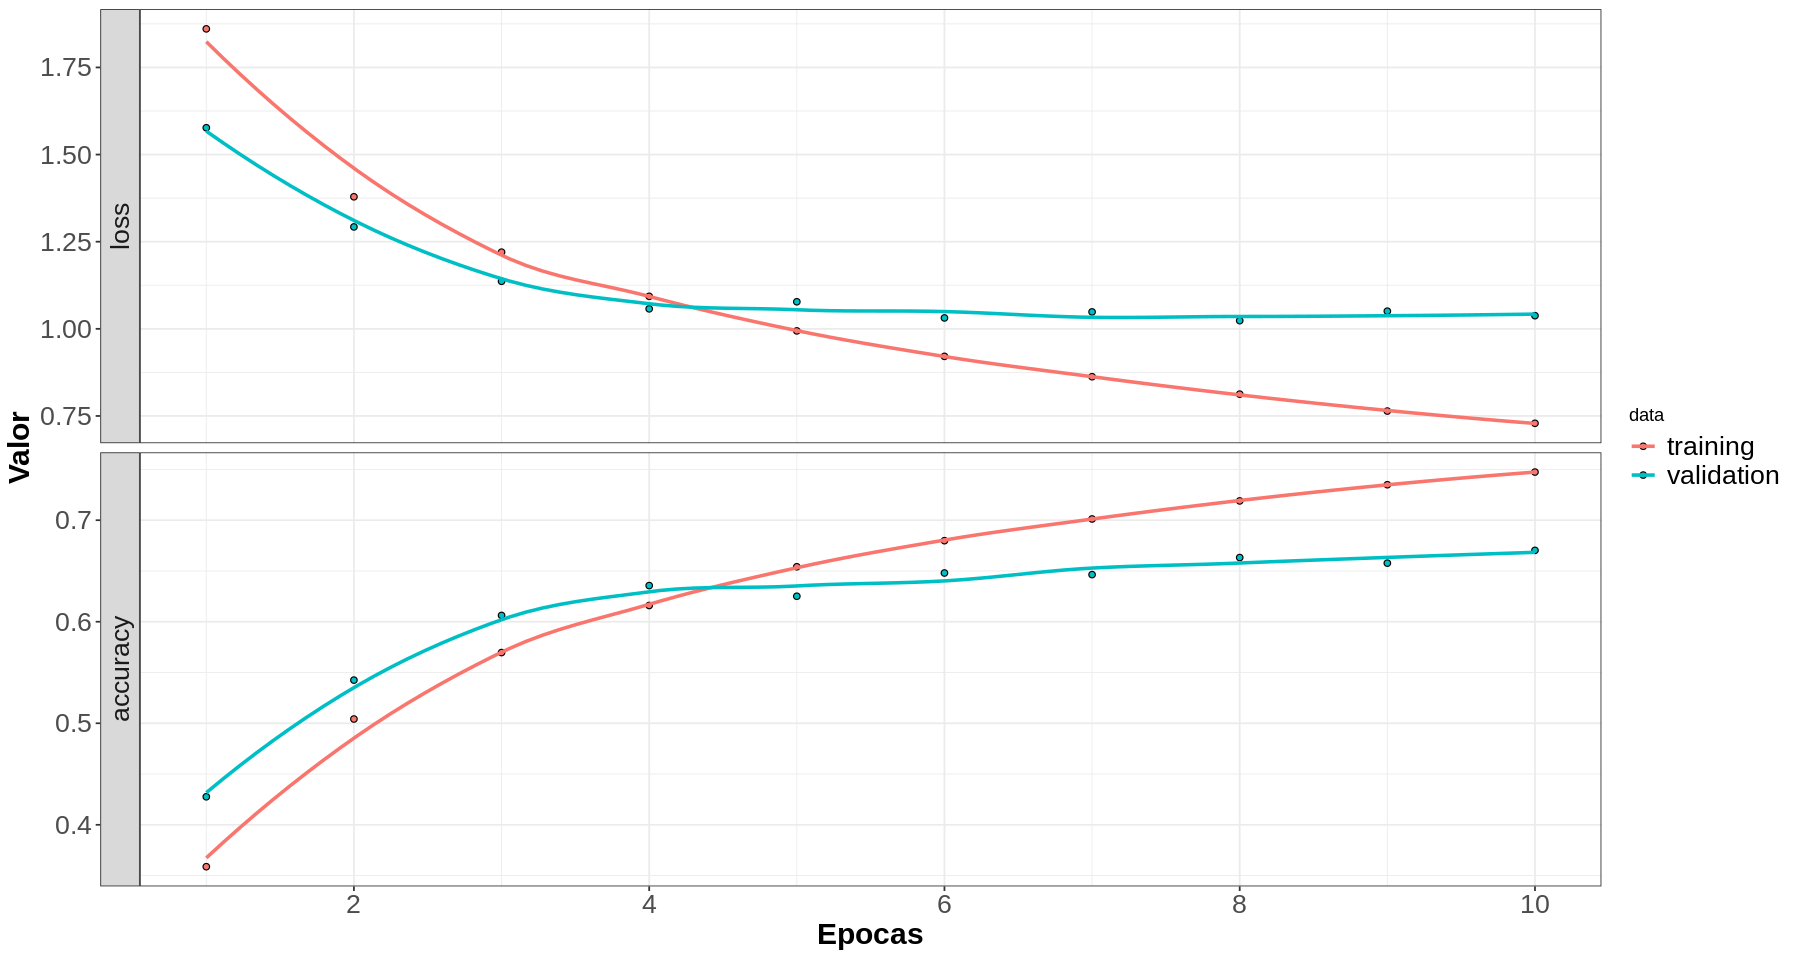

In [ ]:
options(repr.plot.width=15, repr.plot.height=8)
g = plot(history) + theme_bw() + xlab("Epocas") + ylab("Valor")
g = g + theme(axis.text=element_text(size=16),
        axis.title=element_text(size=18,face="bold"),
        legend.text=element_text(size=16),
        strip.text = element_text(size = 16))

g

# 5. Realizando predições com o modelo obtido

Tendo o modelo induzido, por meio do treinamento do algoritmo, vamos agora realizar as predições no conjunto de teste, não usado até então.

Podemos também analisar o desempenho do algoritmo no conjunto de treinamento, para fins didáticos. Abaixo, verificamos primeiro a matriz de confusão com as predições obtidas. Os números que compõem a diagnoal principal são os exemplos que foram corretamente rotulado.

In [ ]:
# realizando as predicoes no conjunto de teste, só para checagem
# pred = model %>% predict_classes(cifar$train$x)
pred = model %>% predict(cifar$train$x) %>% k_argmax()
print(pred)
# calculando a matriz de confusão


tf.Tensor([6 9 9 ... 9 1 1], shape=(50000), dtype=int64)


In [ ]:
class(pred)

[1] "tensorflow.tensor"                               
[2] "tensorflow.python.framework.ops.EagerTensor"     
[3] "tensorflow.python.framework.ops._EagerTensorBase"
[4] "tensorflow.python.framework.ops.Tensor"          
[5] "tensorflow.python.types.internal.NativeObject"   
[6] "tensorflow.python.types.core.Tensor"             
[7] "python.builtin.object"

In [ ]:
# matriz de confusão
tab1 = table(Predicted=as.numeric(pred), Actual=cifar$train$y)
print(tab1)

         Actual
Predicted    0    1    2    3    4    5    6    7    8    9
        0 3529   12  127   25   40    5    5    8  116   42
        1  125 4571   11   19   16   15   16    6  115  284
        2  297   12 3625  244  314  151  199   80   95   18
        3   87   20  158 2518  131  471   99  107   44   56
        4  186   18  330  421 3948  280  144  367   77   34
        5   70   10  307 1056  128 3723   99  190   25   18
        6   67   57  247  450  208  144 4406   23   49   46
        7   64   12  125  147  182  167   15 4164   12   24
        8  313   93   38   49   12   18    4   13 4266   54
        9  262  195   32   71   21   26   13   42  201 4424


A partir da matriz de confusão conseguimos mensurar a **acurácia** do modelo - numero de acertos/numero de exemplos. O número de acertos é obtido pela soma dos elementos da diagonal principal da matriz. E o número de elemento, sabemos tanto pelo conjunto de teste, como o somatório de todos os elementos da matriz de confusão. Assim, a acurácia do nosso modelo seria:

In [ ]:
acc = sum(diag(tab1))/sum(tab1)
cat("Acurácia do modelo = ", acc, "\n")

Acurácia do modelo =  0.78348 


E, as vezes também é interessante visualizar as predições para cada amostra/exemplo a fim de identificar potenciais erros ou rúidos que podem ser trabalhados para melhorar o desempenho do modelo induzido. Abaixo, executamos alguns comandos para ver qual é a probabilidade de um exemplo pertencer a qualquer uma das 10 classes. As duas últimas colunas indicam o valor predito (Predicted) e o valor real esperado (Truth) que será o label correto para aquele exemplo.

In [ ]:
# obtendo as predicoes, mas em termos de probabilidades
prob = model %>% predict(cifar$train$x)
head(prob)

5.101298e-06,1.401642e-05,2.358127e-03,1.265841e-02,1.651036e-03,2.185454e-01,7.640693e-01,6.817314e-04,1.074394e-05,6.080834e-06
9.225750e-04,4.106342e-03,9.637094e-04,4.613641e-03,3.714727e-04,7.814112e-04,4.684746e-05,4.563997e-04,4.497071e-04,9.872879e-01
1.995224e-03,1.080985e-02,7.859857e-02,1.065906e-01,1.779199e-03,8.111006e-02,9.697714e-02,1.316553e-02,2.754171e-04,6.086984e-01
5.660628e-03,9.381695e-04,4.036688e-02,3.000236e-02,8.263762e-01,4.770032e-02,1.734361e-02,2.749414e-02,2.252406e-03,1.865324e-03
1.181144e-10,9.999982e-01,1.048179e-18,2.100040e-16,5.367382e-18,2.001395e-18,5.052762e-17,1.215507e-16,6.093795e-13,1.751745e-06
2.585088e-05,9.976450e-01,3.572816e-06,2.137923e-06,4.457966e-07,5.174518e-07,1.606618e-06,3.241187e-07,7.953668e-05,2.240990e-03


In [ ]:
df = cbind(prob, Predicted_class = as.numeric(pred), Actual=cifar$train$y)
head(df)

,,,,,,,,,,Predicted_class,
5.101298e-06,1.401642e-05,2.358127e-03,1.265841e-02,1.651036e-03,2.185454e-01,7.640693e-01,6.817314e-04,1.074394e-05,6.080834e-06,6,6
9.225750e-04,4.106342e-03,9.637094e-04,4.613641e-03,3.714727e-04,7.814112e-04,4.684746e-05,4.563997e-04,4.497071e-04,9.872879e-01,9,9
1.995224e-03,1.080985e-02,7.859857e-02,1.065906e-01,1.779199e-03,8.111006e-02,9.697714e-02,1.316553e-02,2.754171e-04,6.086984e-01,9,9
5.660628e-03,9.381695e-04,4.036688e-02,3.000236e-02,8.263762e-01,4.770032e-02,1.734361e-02,2.749414e-02,2.252406e-03,1.865324e-03,4,4
1.181144e-10,9.999982e-01,1.048179e-18,2.100040e-16,5.367382e-18,2.001395e-18,5.052762e-17,1.215507e-16,6.093795e-13,1.751745e-06,1,1
2.585088e-05,9.976450e-01,3.572816e-06,2.137923e-06,4.457966e-07,5.174518e-07,1.606618e-06,3.241187e-07,7.953668e-05,2.240990e-03,1,1


In [ ]:
# verificando as predicoes, em termos de probabilidades para cada um dos exemplos
colnames(df)[1:10] = paste("Prob", class_names, sep=".")
colnames(df)[11:12] = c("Predicted", "Truth")
head(round(df, 5))

Prob.airplane,Prob.automobile,Prob.bird,Prob.cat,Prob.deer,Prob.dog,Prob.frog,Prob.horse,Prob.ship,Prob.truck,Predicted,Truth
0.00001,0.00001,0.00236,0.01266,0.00165,0.21855,0.76407,0.00068,0.00001,0.00001,6,6
0.00092,0.00411,0.00096,0.00461,0.00037,0.00078,0.00005,0.00046,0.00045,0.98729,9,9
0.00200,0.01081,0.07860,0.10659,0.00178,0.08111,0.09698,0.01317,0.00028,0.60870,9,9
0.00566,0.00094,0.04037,0.03000,0.82638,0.04770,0.01734,0.02749,0.00225,0.00187,4,4
0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1,1
0.00003,0.99764,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00008,0.00224,1,1


Entretanto, o mais interessante aqui é avaliar o modelo induzido no **conjunto de teste**. Assim, repetimos os passos descrito acima para ```cifar$test```:
* matriz de confusão das predições;
* acurácia geral do modelo
* predições individuais com a probabilidade de cada classe.


In [ ]:
evaluate(model, cifar$test$x, cifar$test$y, verbose = 0)

loss accuracy 
 1.03765  0.67030

In [ ]:
pred_test = model %>% predict(cifar$test$x) %>% k_argmax()
tab = table(Predicted = as.numeric(pred_test), Actual = cifar$test$y)
print(tab)

         Actual
Predicted   0   1   2   3   4   5   6   7   8   9
        0 573   6  42  13   6   4   2   7  53   8
        1  34 822   8  13   3   4   7   4  42 107
        2  96   7 590  82  87  57  65  22  25  13
        3  25   7  55 365  42 136  27  34  14  15
        4  43   8  92 104 659  62  36 125  26  11
        5  18   3 102 234  44 627  25  82   8   1
        6  27  19  70 112  73  36 824   9  13  16
        7  20   6  28  44  71  55   6 702   9  15
        8  95  36   7  12   8   6   2   2 752  25
        9  69  86   6  21   7  13   6  13  58 789


In [ ]:
acc = sum(diag(tab))/sum(tab)
cat("Acurácia do modelo = ", acc, "\n")

Acurácia do modelo =  0.6703 


In [ ]:
prob2 = model %>% predict(cifar$test$x)
head(prob2)

1.070056e-03,0.0011460966,2.172014e-02,6.306749e-01,1.261376e-02,2.334884e-01,5.864608e-02,1.182469e-02,2.843373e-02,3.820539e-04
1.097354e-04,0.0038298878,1.571844e-07,4.749961e-08,1.085753e-08,2.937381e-09,1.655111e-09,1.683959e-07,9.933339e-01,2.725977e-03
6.182896e-02,0.2268892378,1.069068e-02,1.835828e-02,1.447615e-03,1.173909e-03,7.231294e-03,2.795621e-03,6.125717e-01,5.701262e-02
8.900652e-01,0.0155517142,1.731681e-02,3.880584e-03,3.010021e-03,1.120442e-03,1.404853e-02,1.172193e-04,5.042986e-02,4.459655e-03
1.509452e-04,0.0001083227,1.690409e-02,2.662129e-03,7.523121e-01,2.389177e-03,2.249081e-01,1.731813e-04,3.883997e-04,3.705839e-06
4.570564e-05,0.0005523141,1.496414e-02,2.581850e-02,4.593458e-03,2.614739e-02,9.184520e-01,9.001208e-03,1.553513e-05,4.096725e-04


In [ ]:
df2 = cbind(prob2, Predicted_class = as.numeric(pred_test), Actual=cifar$test$y)
# verificando as predicoes, em termos de probabilidades para cada um dos exemplos
colnames(df2)[1:10] = paste("Prob", class_names, sep=".")
colnames(df2)[11:12] = c("Predicted", "Truth")
head(round(df2, 5))

Prob.airplane,Prob.automobile,Prob.bird,Prob.cat,Prob.deer,Prob.dog,Prob.frog,Prob.horse,Prob.ship,Prob.truck,Predicted,Truth
0.00107,0.00115,0.02172,0.63067,0.01261,0.23349,0.05865,0.01182,0.02843,0.00038,3,3
0.00011,0.00383,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.99333,0.00273,8,8
0.06183,0.22689,0.01069,0.01836,0.00145,0.00117,0.00723,0.00280,0.61257,0.05701,8,8
0.89007,0.01555,0.01732,0.00388,0.00301,0.00112,0.01405,0.00012,0.05043,0.00446,0,0
0.00015,0.00011,0.01690,0.00266,0.75231,0.00239,0.22491,0.00017,0.00039,0.00000,4,6
0.00005,0.00055,0.01496,0.02582,0.00459,0.02615,0.91845,0.00900,0.00002,0.00041,6,6


#6. Síntese e considerações finais

No exemplo aqui demonstrado aplicamos uma CNN para realizar uma tarefa de classificação de imagens. O dataset que exploramos foi o CIFAR-10, com imagens originalmente categorizadas em 10 classes distintas.

Nosso passo a passo de indução e avaliação de um modelo é feito epxlorando as implementações do keras, bilioteca original do Python, mas com pacote disponível que realiza o interfaceamento com R.

Basicamente seguimos um fluxo padrão de geração/indução de modelo preditivo:
1.  Obtenção dos dados (CIFAR-10);
2.  Separação dos dados entre conjuntos de treino e teste (```cifar$train``` e ```cifar$test```);
3.  Criação de um modelo inicial com a arquitetura padrão de CNN. Definimos um modelo sequencial (forward) e adicionamos cada uma das camadas da CNN, especificando a quantidade de neurônios, tamanho de possíveis kernels, e os correspondentes tipos de funções de ativação;
4.  Definição dos parâmetros usados no treinamento do algoritmo (algoritmo de otimização/redução do erro, medida reduzida, e medidas de desempenho)
5.  Treinamento e indução do modelo preditivo (```fit```); e
5.  Avaliação do modelo induzido no cojunto de testes (predições e probabilidades).

Por fim, é importante salientar que grande parte dos processos acima descritos são facilitados pelas ferramentas que exploramos (keras). Isso é imprescíndicel para um programador/cientista de dados/pesquisador, pois permite que nos dediquemos ao estudo do problema e das possíveis implicações dos modelos gerados, uma vez que a modelagem/implementação já é fornecida por uma ferramenta robusta. Como diriam alguns professores com que já trabalhei ao longo da vida:

  "*Não precisamos reinventar a roda, mas saber usar o que já existe e expandir a fronteira do conhecimento*".

Bons estudos :)
